# Arboles de decisión

Este notebook realiza un análisis EDA y determina si el paciente tiene o no Diabetes

## 1. Importar librerías necesarias

Importamos las librerías principales para análisis y visualización de datos.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from pickle import dump
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

## 2. Carga e inspección inicial de los datos

Cargamos el archivo CSV y mostramos las primeras y últimas filas para una vista preliminar.

In [2]:
df = pd.read_csv("../data/raw/diabetes dtree.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


## 3. Tamaño y estructura del dataset

Mostramos el número de filas y columnas, y la estructura general del DataFrame.

In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 4. Tipos de datos y valores nulos

Revisamos los tipos de datos de cada columna y verificamos la existencia de valores nulos o faltantes.

In [7]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Valores nulos

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
print((df == 0).sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


### Mostrar los valores únicos de todas las columnas

In [10]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}\n")

Pregnancies: [ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]

Glucose: [148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]

BloodPressure: [ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114]

SkinThickness: [35 29  0 23 32 45 19 47 38 30 41 33 26 15 36 11 31 37 42 25 18 24 39 27
 21 34 10 60 13 20 22 28 54 40 51 56 14 17 50 44 12 46 16  7 52 43 48  8
 

## 5. Estadísticas descriptivas

Obtenemos estadísticas descriptivas de las variables numéricas.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


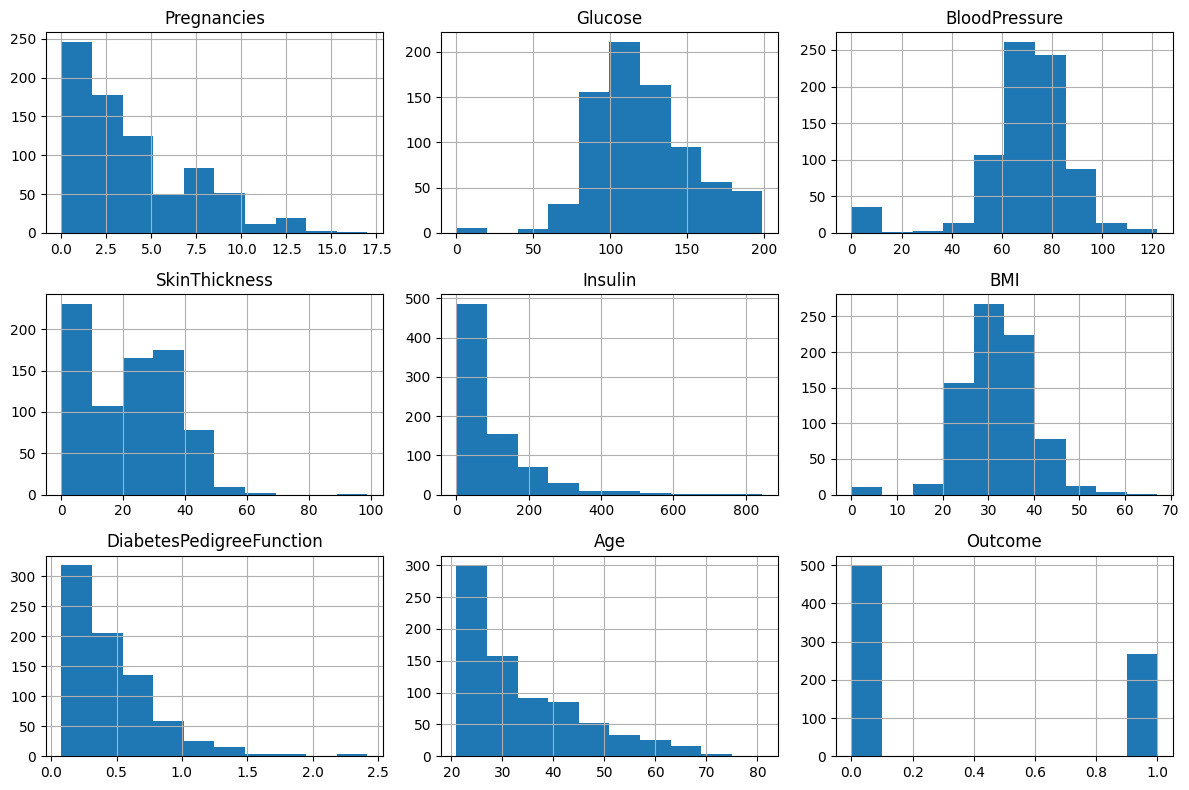

In [12]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

### Correlación entre variables numéricas

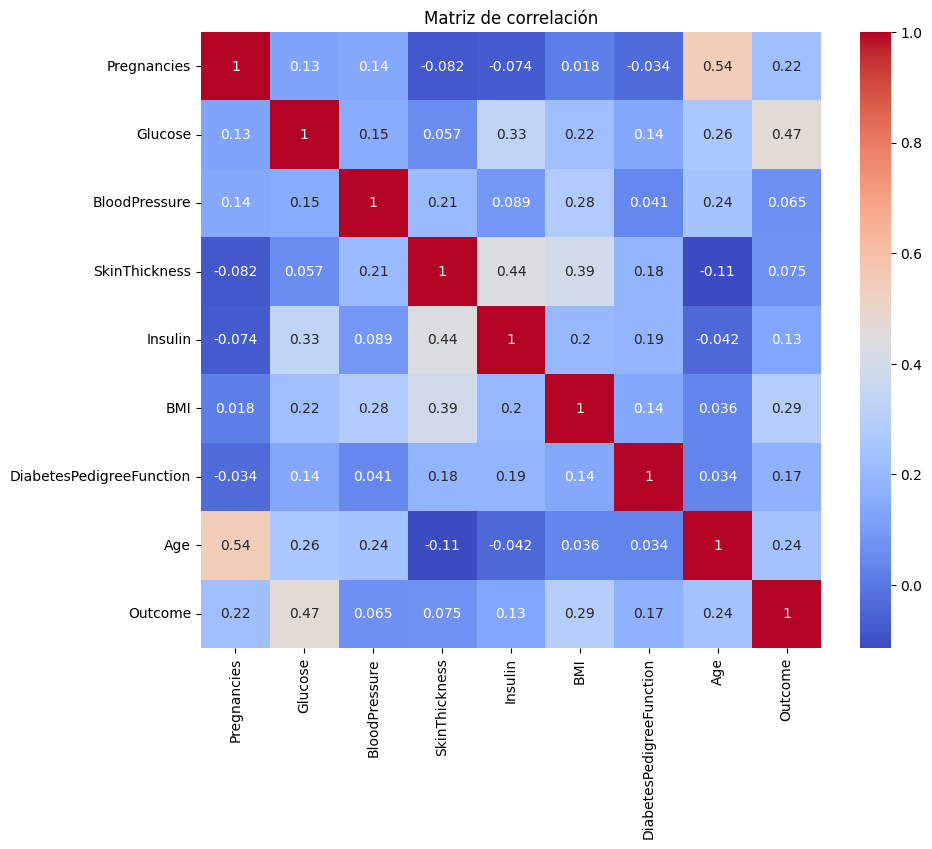

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

## Elegimos Outcome como variable objetivo

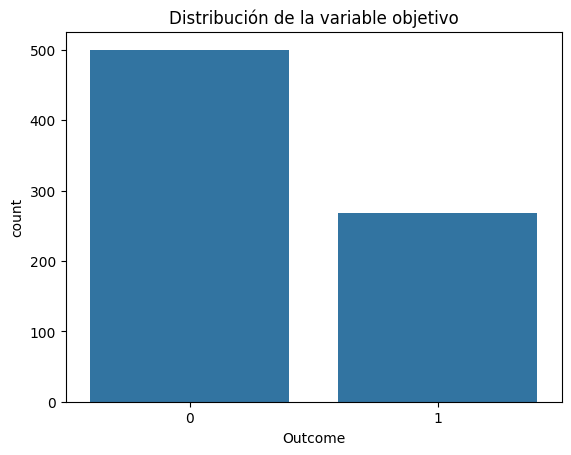

In [14]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribución de la variable objetivo')
plt.show()

### Relación entre variables y variable objetivo

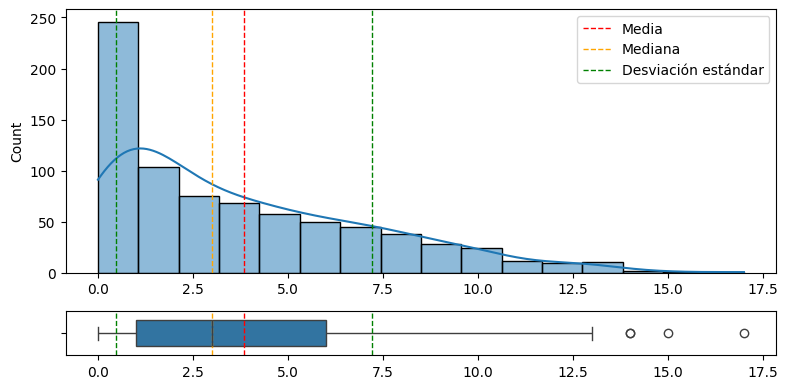

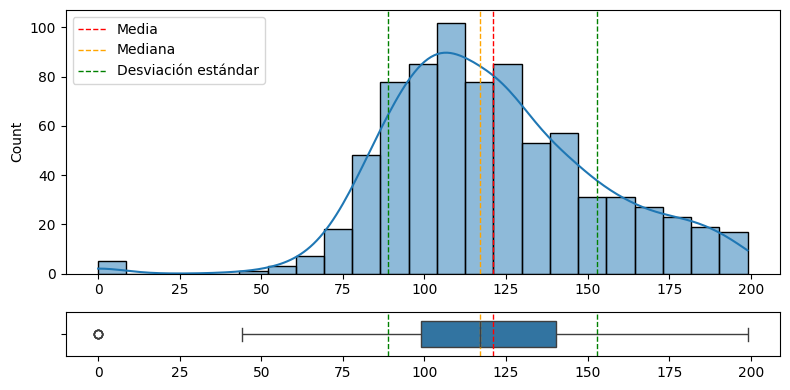

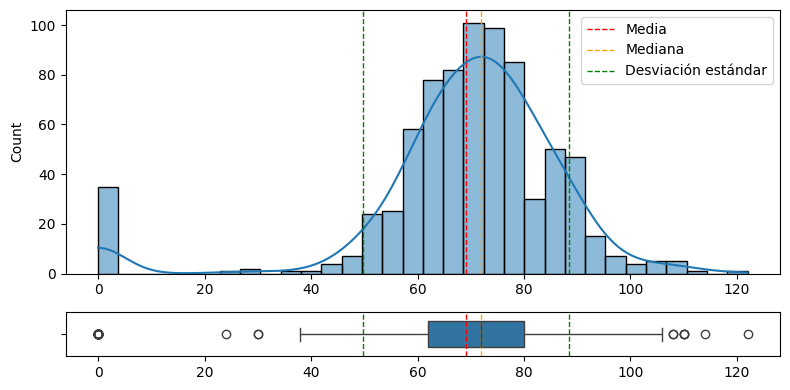

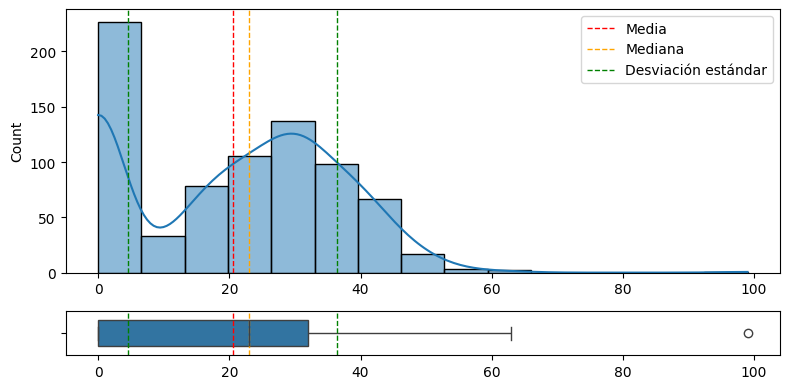

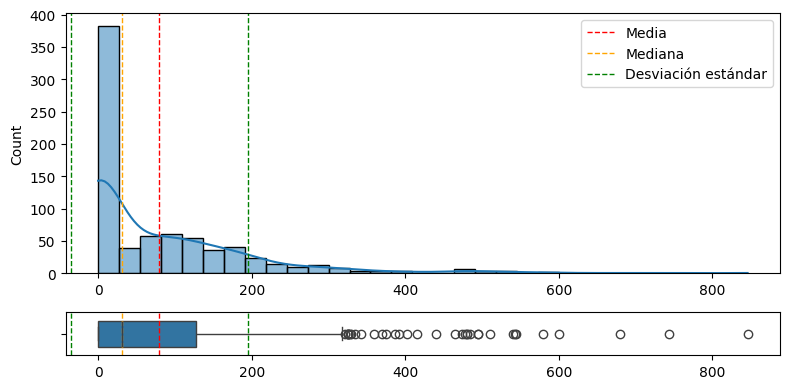

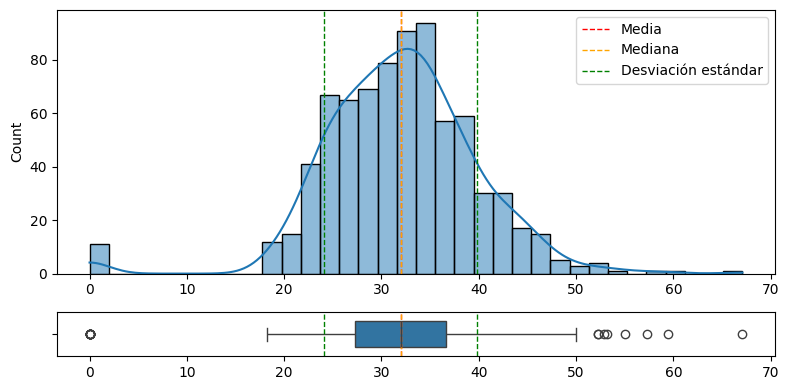

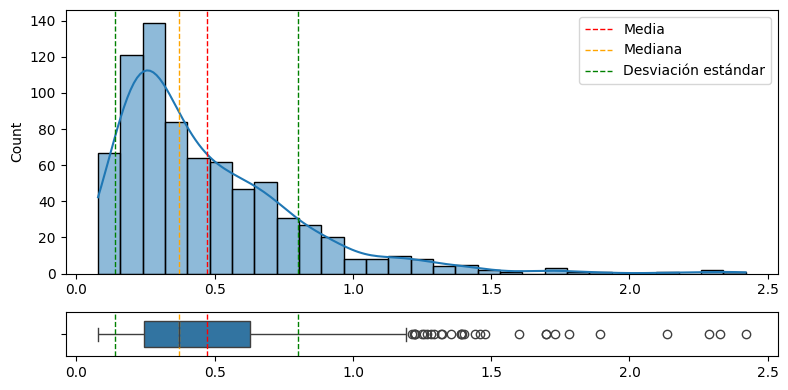

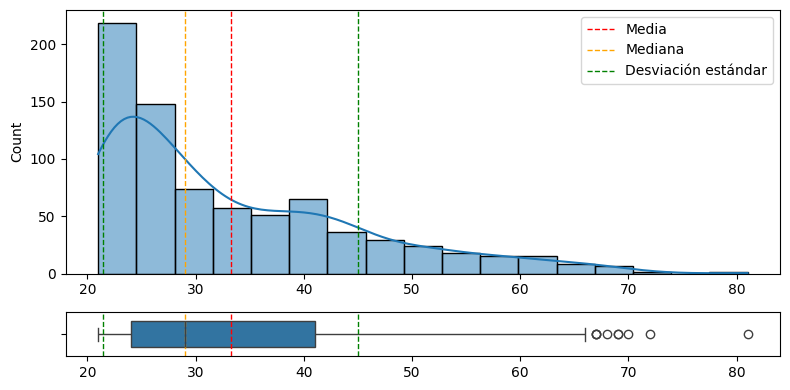

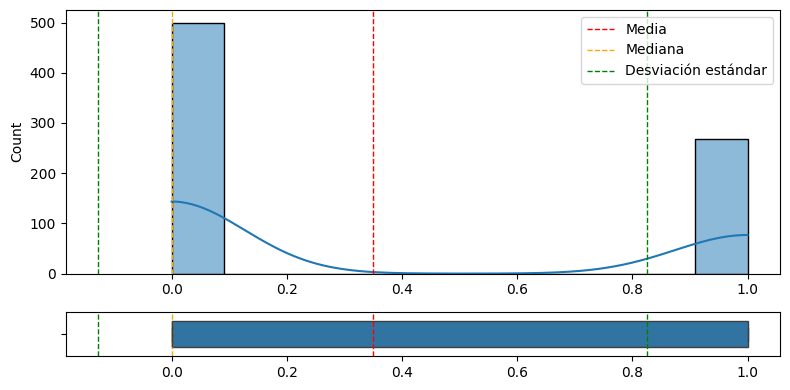

In [15]:
def plot_numerical_data(dataframe):
    numerical_columns = dataframe.select_dtypes(include=['float64', 'int64']).columns

    for column in numerical_columns:
        fig, axis = plt.subplots(2, 1, figsize=(8, 4), gridspec_kw={'height_ratios': [6, 1]})

        # Calcular media, mediana y desviación estándar
        mean_val = np.mean(dataframe[column])
        median_val = np.median(dataframe[column])
        std_dev = np.std(dataframe[column])

        # Histograma
        sns.histplot(ax=axis[0], data=dataframe, kde=True, x=column).set(xlabel=None)
        axis[0].axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label='Media')
        axis[0].axvline(median_val, color='orange', linestyle='dashed', linewidth=1, label='Mediana')
        axis[0].axvline(mean_val + std_dev, color='green', linestyle='dashed', linewidth=1, label='Desviación estándar')
        axis[0].axvline(mean_val - std_dev, color='green', linestyle='dashed', linewidth=1)

        # Boxplot
        sns.boxplot(ax=axis[1], data=dataframe, x=column, width=0.6).set(xlabel=None)
        axis[1].axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label='Media')
        axis[1].axvline(median_val, color='orange', linestyle='dashed', linewidth=1, label='Mediana')
        axis[1].axvline(mean_val + std_dev, color='green', linestyle='dashed', linewidth=1)
        axis[1].axvline(mean_val - std_dev, color='green', linestyle='dashed', linewidth=1)

        axis[0].legend()
        plt.tight_layout()
        plt.show()


plot_numerical_data(df)

### Identificación de variables altamente correlacionadas

> Enlistamos descendientemente la correlación con Outcome de cada variable

In [16]:
corr_outcome = df.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
corr_outcome

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

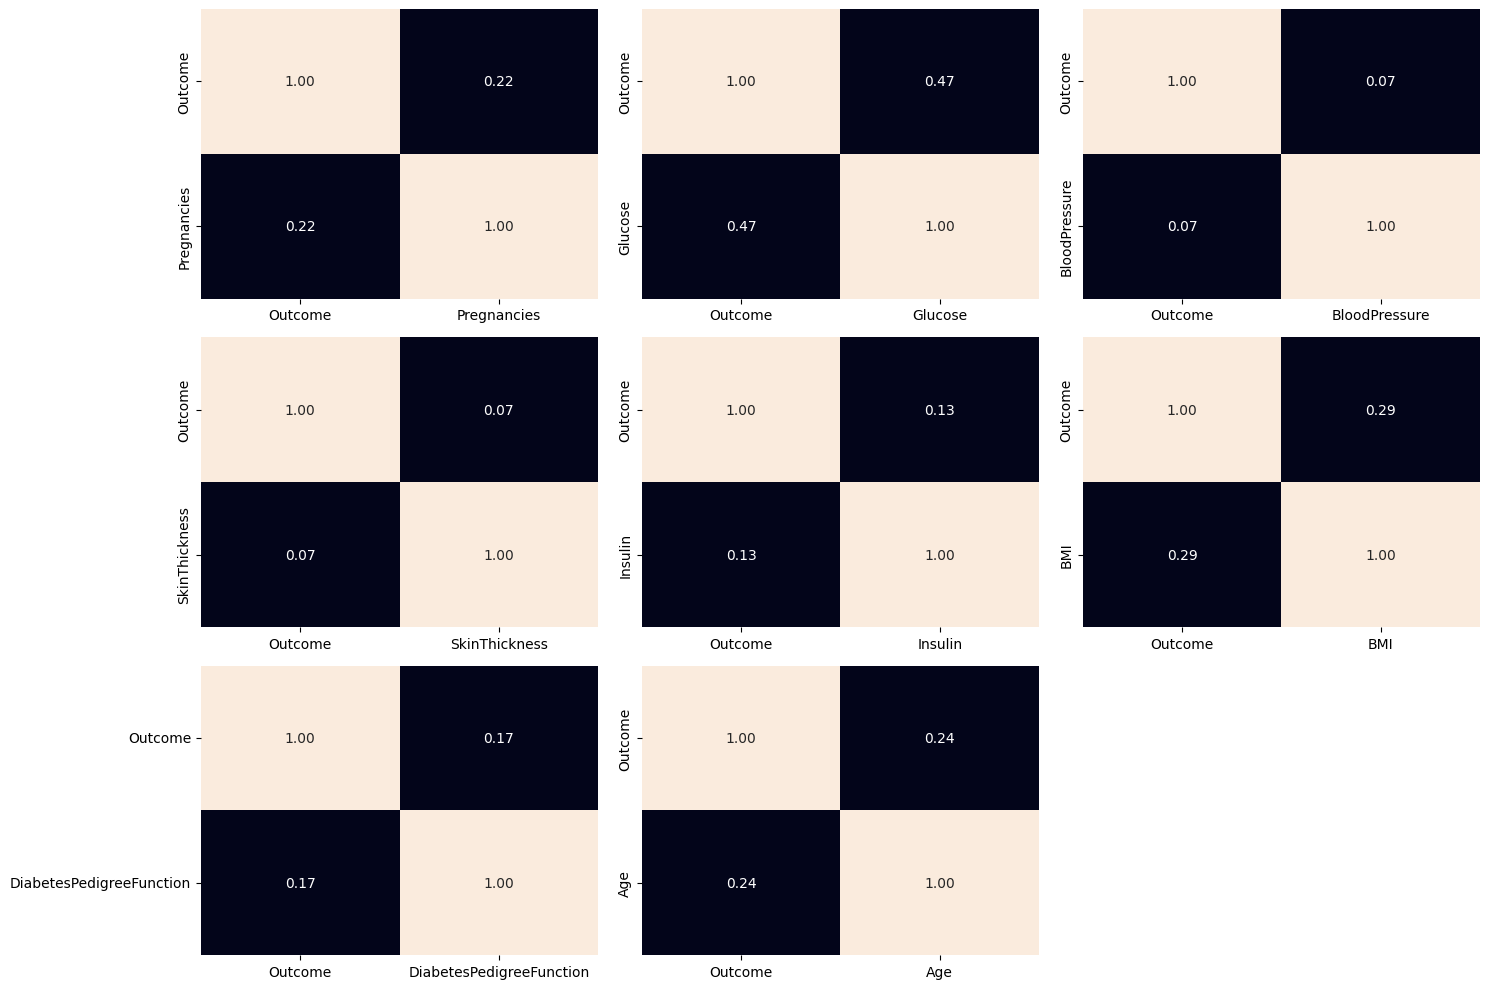

In [17]:
numeric_variables = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
plt.figure(figsize=(15, 10))
for i, variable in enumerate(numeric_variables, 1):
    plt.subplot(3, 3, i)
    sns.heatmap(df[["Outcome", variable]].corr(), annot=True, fmt=".2f", cbar=False)

plt.tight_layout()
plt.show()

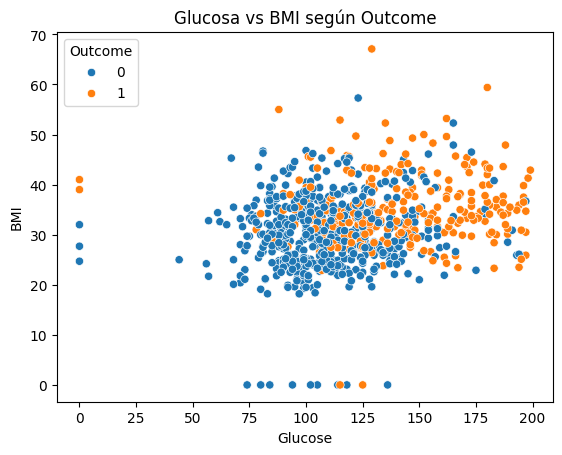

In [18]:
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title('Glucosa vs BMI según Outcome')
plt.show()

##### Podemos concluir que los pacientes con alta glucosa y alto bmi tienen tendecia a tener diabetes

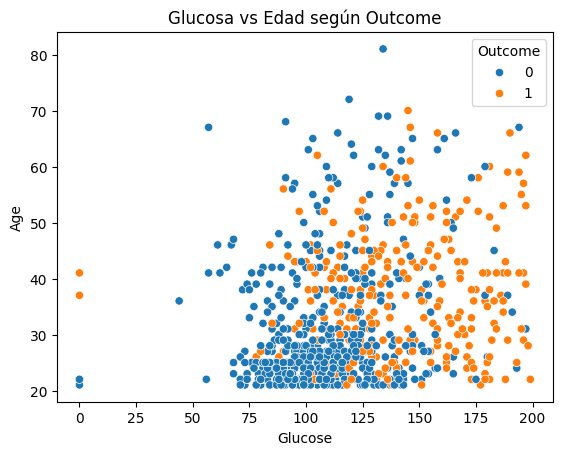

In [19]:
sns.scatterplot(x='Glucose', y='Age', hue='Outcome', data=df)
plt.title('Glucosa vs Edad según Outcome')
plt.show()

##### Las edades menores a 30 y con glucosa entre 75 y 150 no padecen diabetes. Mayores a 30 y >125 de glucosa presentan una alta probabilidad.

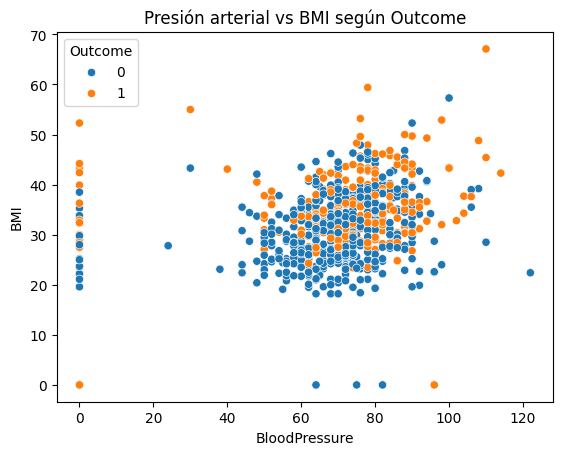

In [20]:
sns.scatterplot(x='BloodPressure', y='BMI', hue='Outcome', data=df)
plt.title('Presión arterial vs BMI según Outcome')
plt.show()

##### Pacientes con mayor BMI tienen mayor probabilidad de tener diabetes, independientemente de su presión arterial. La presión arterial no parece ser un factor tan determinante como el BMI.

## Exploración con XGBOOSTING

> Lectura y procesamiento del Dataset

In [21]:
df_knn = df.copy()

##### Selección de columnas con 0

In [35]:
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

##### Reemplazo de 0's y aplicacion de KNNImputer

In [36]:
df_knn[cols_con_ceros] = df_knn[cols_con_ceros].replace(0, np.nan)
imputer = KNNImputer(n_neighbors=5)
df_knn[cols_con_ceros] = imputer.fit_transform(df_knn[cols_con_ceros])

In [37]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [38]:
X_knn = df_knn.drop(columns=['Outcome'])
y_knn = df_knn['Outcome']

#### División en entrenamiento y prueba

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

#### Entrenar el modelo

In [ ]:
model = GradientBoostingClassifier(
    n_estimators=15,      
    learning_rate=0.05,    # tasa de aprendizaje más baja
    max_depth=4,           # árboles más profundos
    min_samples_split=3,   # mínimo 3 muestras para dividir
    min_samples_leaf=2,    # mínimo 2 muestras en hoja
    subsample=0.8,         # usa el 80% de los datos en cada árbol
    random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7792207792207793
Confusion Matrix:
 [[88 11]
 [23 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.89      0.84        99
           1       0.74      0.58      0.65        55

    accuracy                           0.78       154
   macro avg       0.77      0.74      0.75       154
weighted avg       0.78      0.78      0.77       154



In [54]:
model_2 = GradientBoostingClassifier(
    n_estimators=15,      
    learning_rate=0.05,    # tasa de aprendizaje más baja
    max_depth=4,           # árboles más profundos
    min_samples_split=3,   # mínimo 3 muestras para dividir
    min_samples_leaf=2,    # mínimo 2 muestras en hoja
    subsample=0.8,         # usa el 80% de los datos en cada árbol
    random_state=42)

model_2.fit(X_train_2, y_train_2)

y_pred_2 = model_2.predict(X_test_2)
print("Accuracy:", accuracy_score(y_test_2, y_pred_2))
print("Confusion Matrix:\n", confusion_matrix(y_test_2, y_pred_2))
print("Classification Report:\n", classification_report(y_test_2, y_pred_2))


Accuracy: 0.7792207792207793
Confusion Matrix:
 [[86 13]
 [21 34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.87      0.83        99
           1       0.72      0.62      0.67        55

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.78      0.78      0.77       154



### Tabla comparativa entre los 2 modelos

In [80]:
metrics = {
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test_2, y_pred_2)],
    "Precision": [classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
                  classification_report(y_test_2, y_pred_2, output_dict=True)['1']['precision']],
    "Recall": [classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
               classification_report(y_test_2, y_pred_2, output_dict=True)['1']['recall']],
    "F1-score": [classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
                 classification_report(y_test_2, y_pred_2, output_dict=True)['1']['f1-score']]}
df_comparacion = pd.DataFrame(metrics, index=["model", "model_2"])
df_comparacion

,Accuracy,Precision,Recall,F1-score
model,0.746753,0.621212,0.745455,0.677686
model_2,0.753247,0.623188,0.781818,0.693548



> Al encontrar mucha variación de las métricas al variar los hiper parámetros procedemos a iterar con rangos para estimar el mejor valor.

In [78]:
param_dist = {
    'n_estimators': list(range(10, 30, 5)),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': list(range(2, 7)),
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'subsample': [0.6, 0.8, 1.0]}

# Instancia el modelo base
gbc = GradientBoostingClassifier(random_state=42)

# Instancia RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=param_dist,
    n_iter=30,             # Número de combinaciones aleatorias a probar
    cv=3,                  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42)

# Ajusta el random search al set de entrenamiento
random_search.fit(X_train, y_train)

# mejor modelo encontrado:
best_model = random_search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END learning_rate=0.2, max_depth=3, min_samples_leaf=4, min_samples_split=2, n_estimators=20, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.2, max_depth=3, min_samples_leaf=4, min_samples_split=2, n_estimators=20, subsample=0.6; total time=   0.1s
[CV] END learning_rate=0.2, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=15, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.2, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=15, subsample=0.6; total time=   0.1s
[CV] END learning_rate=0.2, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=15, subsample=0.6; total time=   0.1s
[CV] END learning_rate=0.2, max_depth=3, min_samples_leaf=4, min_samples_split=2, n_estimators=20, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=6, min_samples_leaf=2, min_samples_split=10, n_estimators=20, subsample=1.0; total time=   0.1s
[CV] E

#### Encontrados los mejores hiperparámetros, volvemos a entrenar en ambos modelos. Adicionalmente le damos más peso a los valores positivos diabéticos ya que es el objetivo.

In [73]:
best_params = random_search.best_params_
# Calcula los pesos para y_train y y_train_2
weights = np.where(y_train == 1, 2, 1)      # Clase 1 pesa el doble
weights_2 = np.where(y_train_2 == 1, 2, 1)  # Clase 1 pesa el doble


#### Model

In [74]:
model = GradientBoostingClassifier(**best_params, random_state=42)
model.fit(X_train, y_train, sample_weight=weights)
y_pred = model.predict(X_test)
print("Resultados con datos originales (pesos):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Resultados con datos originales (pesos):
Accuracy: 0.7467532467532467
Confusion Matrix:
 [[74 25]
 [14 41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.75      0.79        99
           1       0.62      0.75      0.68        55

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75      0.75       154



#### Model_2

In [75]:

model_2 = GradientBoostingClassifier(**best_params, random_state=42)
model_2.fit(X_train_2, y_train_2, sample_weight=weights_2)
y_pred_2 = model_2.predict(X_test_2)
print("\nResultados con datos imputados (pesos):")
print("Accuracy:", accuracy_score(y_test_2, y_pred_2))
print("Confusion Matrix:\n", confusion_matrix(y_test_2, y_pred_2))
print("Classification Report:\n", classification_report(y_test_2, y_pred_2))


Resultados con datos imputados (pesos):
Accuracy: 0.7532467532467533
Confusion Matrix:
 [[73 26]
 [12 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.79        99
           1       0.62      0.78      0.69        55

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.77      0.75      0.76       154



In [79]:
metrics_improved = {
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test_2, y_pred_2)],
    "Precision": [classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
                  classification_report(y_test_2, y_pred_2, output_dict=True)['1']['precision']],
    "Recall": [classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
               classification_report(y_test_2, y_pred_2, output_dict=True)['1']['recall']],
    "F1-score": [classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
                 classification_report(y_test_2, y_pred_2, output_dict=True)['1']['f1-score']]}
df_comparacion_improved = pd.DataFrame(metrics_improved, index=["model", "model_2"])
df_comparacion_improved

,Accuracy,Precision,Recall,F1-score
model,0.746753,0.621212,0.745455,0.677686
model_2,0.753247,0.623188,0.781818,0.693548


#### Conclusión

> Al darle más peso al análisis de los verdaderos positivos logramos mejorar el recall del diagnóstico por diabetes tanto en model, como en model_2. Llegando a un 78% de verdaderos positivos.

### Guardar el modelo

In [77]:
dump(model, open("xg_booster_classifier.sav", "wb"))